In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main"))

In [3]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-05-18.csv')

/tmp/ipykernel_588411/423838941.py:1: DtypeWarning: Columns (0,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,723,724) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-05-18.csv')


In [13]:
# Focus on 1 plate 1 light regime (2h-2h)(plate1)
plate = '33v2'
light = '10min-10min'
df = data[(data['plate'].astype(str)==plate)&(data['light_regime']==light)]



In [15]:
from Scripts_Imane import Format_Data

df = Format_Data.get_format_data(df)

In [16]:
folder = '/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Design_Matrices/'
for fname in os.listdir(folder):
    if (plate in fname) and (light in fname):
        dm = pd.read_csv(os.path.join(folder, fname), sep=';')
        dm['Date'] = pd.to_datetime(dm['Date'], format='%d.%m.%y')

In [19]:
dm

,Date,Time,No.,PAR,F1,F2,F3,F4,F5,F6,...,Fm'6,Fm'7,Y(II)1,Y(II)2,Y(II)3,Y(II)4,Y(II)5,Y(II)6,Y(II)7,Unnamed: 25
0,2024-10-25,10:26:34,1,0,0.0396,0.0435,0.0440,0.0327,0.0411,0.0611,...,0.1882,0.2072,0.675,0.663,0.664,0.644,0.659,0.675,0.667,NaN
1,2024-10-25,10:36:34,2,121,0.0591,0.0630,0.0630,0.0445,0.0591,0.0821,...,0.1149,0.1388,0.313,0.263,0.279,0.266,0.267,0.285,0.285,NaN
2,2024-10-25,10:46:35,3,0,0.0406,0.0445,0.0440,0.0313,0.0411,0.0606,...,0.1628,0.1779,0.579,0.597,0.602,0.600,0.598,0.628,0.624,NaN
3,2024-10-25,10:56:36,4,121,0.0606,0.0591,0.0635,0.0415,0.0591,0.0802,...,0.1109,0.1325,0.275,0.301,0.240,0.320,0.234,0.278,0.266,NaN
4,2024-10-25,11:06:37,5,0,0.0347,0.0440,0.0411,0.0293,0.0401,0.0606,...,0.1544,0.1706,0.641,0.607,0.635,0.618,0.608,0.608,0.602,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,2024-10-26,05:48:12,82,0,0.0450,0.0489,0.0479,0.0323,0.0459,0.0670,...,0.1716,0.1882,0.576,0.609,0.593,0.614,0.593,0.610,0.605,NaN
82,2024-10-26,05:58:13,83,121,0.0640,0.0699,0.0684,0.0445,0.0621,0.0885,...,0.1149,0.1359,0.268,0.239,0.213,0.266,0.235,0.230,0.266,NaN
83,2024-10-26,06:18:14,84,121,0.0645,0.0660,0.0650,0.0455,0.0587,0.0904,...,0.1163,0.1320,0.246,0.266,0.240,0.244,0.290,0.223,0.233,NaN
84,2024-10-26,06:28:15,85,0,0.0415,0.0503,0.0459,0.0327,0.0484,0.0660,...,0.1706,0.1857,0.626,0.607,0.607,0.604,0.560,0.613,0.613,NaN


In [22]:
df['measurement_time_82']

107766   2024-10-26 05:58:13
107767   2024-10-26 05:58:13
107768   2024-10-26 05:58:13
107769   2024-10-26 05:58:13
107770   2024-10-26 05:58:13
                 ...        
108144   2024-10-26 05:58:13
108145   2024-10-26 05:58:13
108146   2024-10-26 05:58:13
108147   2024-10-26 05:58:13
108148   2024-10-26 05:58:13
Name: measurement_time_82, Length: 368, dtype: datetime64[ns]

In [23]:
print(min(df['start_date']), max(df['start_date']))

print(min(df['measurement_time_1']), max(df['start_date']))

print(min(dm['Date']), max(dm['Date']))
print(min(dm['Time']), max(dm['Time']))


2024-10-25 2024-10-25
2024-10-25 10:36:34 2024-10-25
2024-10-25 00:00:00 2024-10-26 00:00:00
00:17:50 23:57:49


In [24]:
# Étape 1 : Créer une colonne light_status dans dm
dm['light_status'] = np.where(dm['PAR'] > 0, 'light', 'dark')

# Étape 2 : Mapper directement le statut de lumière à df en fonction de la colonne No.
light_status_cols = []

for col in df.columns:
    if col.startswith('measurement_time_'):
        no_col = str(int(col.replace('measurement_time_', ''))+1)   # Extraire le numéro
        light_status_col_name = f'light_status_{no_col}'

        match = dm.loc[dm['No.'].astype(str) == no_col, 'light_status']
        if not match.empty:
            light_status = match.values[0]
            df[light_status_col_name] = light_status
            light_status_cols.append(light_status_col_name)
        else:
            print(f"Aucun match trouvé pour No. == {no_col}")

# Résultat : df contient maintenant les colonnes light_status_x correspondant à chaque mesure


In [25]:
for e in df.columns:
    print(e)

plate
measurement
start_date
light_regime
dark_threshold
light_threshold
num_frames
i
j
fv_fm
fv_fm_std
mask_area
y2_1
y2_2
y2_3
y2_4
y2_5
y2_6
y2_7
y2_8
y2_9
y2_10
y2_11
y2_12
y2_13
y2_14
y2_15
y2_16
y2_17
y2_18
y2_19
y2_20
y2_21
y2_22
y2_23
y2_24
y2_25
y2_26
y2_27
y2_28
y2_29
y2_30
y2_31
y2_32
y2_33
y2_34
y2_35
y2_36
y2_37
y2_38
y2_39
y2_40
y2_41
y2_42
y2_43
y2_44
y2_45
y2_46
y2_47
y2_48
y2_49
y2_50
y2_51
y2_52
y2_53
y2_54
y2_55
y2_56
y2_57
y2_58
y2_59
y2_60
y2_61
y2_62
y2_63
y2_64
y2_65
y2_66
y2_67
y2_68
y2_69
y2_70
y2_71
y2_72
y2_73
y2_74
y2_75
y2_76
y2_77
y2_78
y2_79
y2_80
y2_81
y2_82
y2_83
y2_84
y2_std_1
y2_std_2
y2_std_3
y2_std_4
y2_std_5
y2_std_6
y2_std_7
y2_std_8
y2_std_9
y2_std_10
y2_std_11
y2_std_12
y2_std_13
y2_std_14
y2_std_15
y2_std_16
y2_std_17
y2_std_18
y2_std_19
y2_std_20
y2_std_21
y2_std_22
y2_std_23
y2_std_24
y2_std_25
y2_std_26
y2_std_27
y2_std_28
y2_std_29
y2_std_30
y2_std_31
y2_std_32
y2_std_33
y2_std_34
y2_std_35
y2_std_36
y2_std_37
y2_std_38
y2_std_39
y2_std_40


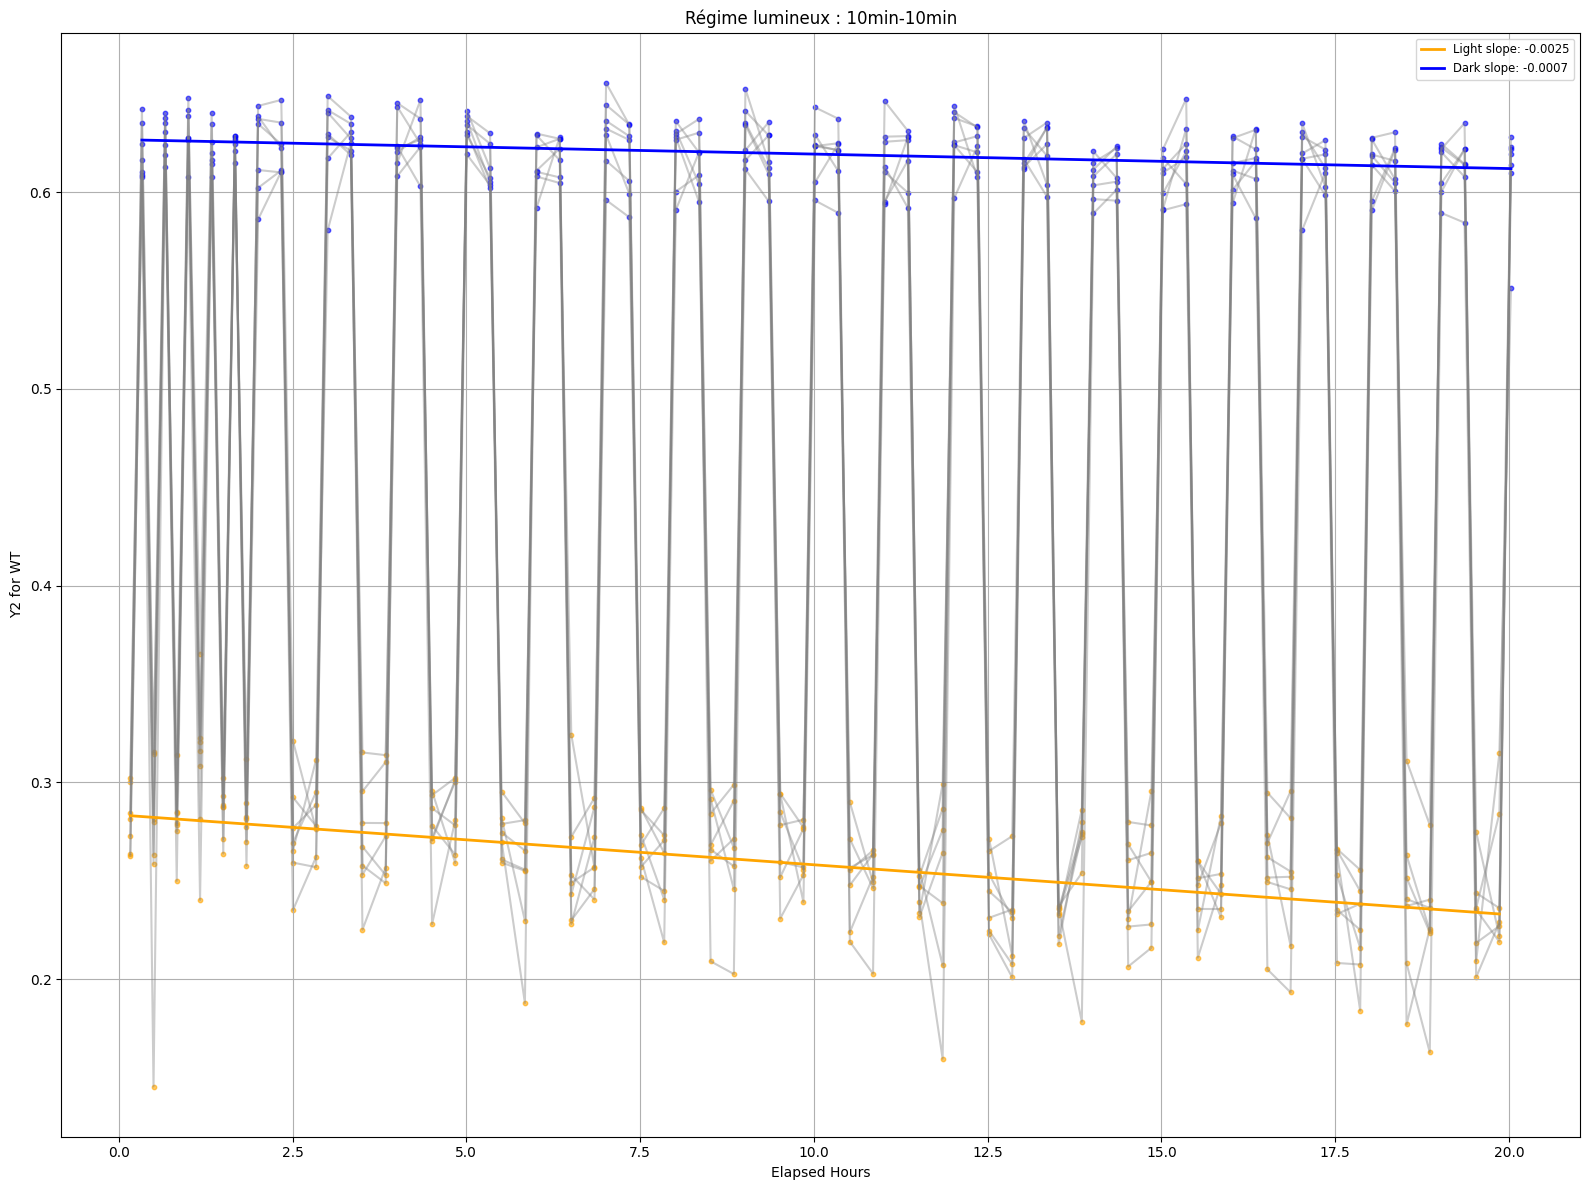

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# --- Préparation des colonnes ---
data = df.copy()

# Colonnes y2 sans les std
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]

# Colonnes temporelles (brutes)
time_columns = [col for col in data.columns if col.startswith('measurement_time_')]
light_status_cols = [col for col in data.columns if col.startswith('light_status_')]

# Convertir les times en datetime
for col in time_columns:
    data[col] = pd.to_datetime(data[col], format='mixed')

# Calcul des heures écoulées
elapsed_hours = data[time_columns].apply(lambda row: (row - row.min()).dt.total_seconds() / 3600, axis=1)
elapsed_hours.columns = [f'elapsed_hours_{i}' for i in range(len(elapsed_hours.columns))]

# Nettoyage des anciennes colonnes si besoin
data = data.drop(columns=[col for col in data.columns if col.startswith("elapsed_hours_")], errors='ignore')
data = pd.concat([data, elapsed_hours], axis=1)

# Colonnes bien ordonnées
elapsed_hours_cols = sorted(
    [col for col in data.columns if col.startswith("elapsed_hours_")],
    key=lambda x: int(x.split("_")[-1])
)

# --- Plot ---
light_regimes = [light]  # définir light ailleurs
fig, axes = plt.subplots(1, figsize=(16, 12))
axes = [axes]

for i, light in enumerate(light_regimes):
    ax = axes[i]
    data_light = data[(data['light_regime'] == light) & (data['plate'].astype(str).str.startswith(plate))]

    for plate in data_light['plate'].unique():
        data_plate = data_light[
            (data_light['mutant_ID'].isin(['WT', 'WT CLiP'])) &
            (data_light['plate'] == plate)
        ]

        all_time, all_y2, all_light = [], [], []

        for _, row in data_plate.iterrows():
            y2_values = row[y2_columns].astype(float).values                  # y2_1 to y2_48
            time_values = row[elapsed_hours_cols[1:]].astype(float).values   # elapsed_hours_1 to _48
            light_status = row[light_status_cols[1:]].astype(str).values     # light_status_1 to _48

            valid = ~np.isnan(time_values) & ~np.isnan(y2_values) & pd.notna(light_status)
            time_values = time_values[valid]
            y2_values = y2_values[valid]
            light_status = light_status[valid]

            all_time.extend(time_values)
            all_y2.extend(y2_values)
            all_light.extend(light_status)

            ax.plot(time_values, y2_values, alpha=0.4, color='gray')
            ax.scatter(time_values[light_status == 'light'], y2_values[light_status == 'light'], color='orange', s=10, alpha=0.6)
            ax.scatter(time_values[light_status == 'dark'], y2_values[light_status == 'dark'], color='blue', s=10, alpha=0.6)

        # Régression séparée pour light/dark
        all_time = np.array(all_time)
        all_y2 = np.array(all_y2)
        all_light = np.array(all_light)

        for condition, color in zip(['light', 'dark'], ['orange', 'blue']):
            cond_mask = all_light == condition
            if cond_mask.sum() >= 2:
                x = all_time[cond_mask].reshape(-1, 1)
                y = all_y2[cond_mask]
                model = LinearRegression().fit(x, y)
                x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
                y_line = model.predict(x_line)
                label = f'{condition.capitalize()} slope: {model.coef_[0]:.4f}'
                ax.plot(x_line, y_line, color=color, linewidth=2, label=label)

    ax.set_title(f'Régime lumineux : {light}')
    ax.set_xlabel('Elapsed Hours')
    ax.set_ylabel('Y2 for WT')
    ax.grid(True)
    ax.legend(fontsize='small', loc='upper right')

plt.tight_layout()
plt.show()
